# 🏥 Lab 16: Event Stream Data — with Real Clinical Data (MEDS)
**BINF 4002 – Machine Learning for Health**

---
## Learning Objectives
1. Understand how clinical histories are represented as **irregularly-spaced event streams**
2. Load and explore the **MIMIC-IV demo dataset** in the **Medical Event Data Standard (MEDS)** format
3. Build **baselines** by tabularizing event streams into fixed-length count/frequency vectors + classical ML
4. Understand the **challenges** unique to event streams: irregular timing, variable length, sparse codes
5. Implement a **temporal embedding** approach that encodes both event identity and timing
6. Implement and train a **Transformer-based** model for event-stream classification
7. Compare tabularization and sequence-model approaches

### Why Event Streams in Healthcare?
A patient's electronic health record (EHR) is fundamentally an **event stream** — a
chronologically ordered sequence of clinical events with **irregular timing**:

```
Day 0:    [Admission, Diagnosis:Pneumonia, Lab:WBC=14.2]
Day 1:    [Medication:Antibiotics, Lab:CRP=85]
Day 3:    [Lab:WBC=10.1, Lab:CRP=42, Imaging:ChestXR]
Day 7:    [Discharge]
Day 30:   [Outpatient_Visit, Lab:WBC=7.5]
```

This is fundamentally different from all prior modalities:
- **Unlike text** (Lab 13): events are not words from a fixed grammar; they have associated
  *timestamps* and *numerical values*; the "vocabulary" is a medical ontology (ICD, CPT, LOINC)
- **Unlike regular time series** (Lab 14): events arrive at *irregular* intervals (minutes to months)
- **Unlike images** (Lab 15): there is no spatial grid; events form a *set with temporal ordering*
- **Unlike graphs** (Lab 12): the primary structure is *temporal*, not topological

### Dataset: MIMIC-IV Demo in MEDS Format
Instead of synthetic data, we use **real (de-identified) clinical data** from the
[MIMIC-IV Clinical Database Demo](https://physionet.org/content/mimic-iv-demo/), converted into
the **Medical Event Data Standard (MEDS)** format.

**MEDS** is a minimal, interoperable schema for EHR event streams with just 5 columns:
- `subject_id` — unique patient identifier
- `time` — timestamp of the event
- `code` — what happened (e.g., `"LAB//51301//K/uL"`, `"DIAGNOSIS//4019"`)
- `numeric_value` — optional measurement (e.g., lab result)
- `text_value` — optional text annotation

The prediction task is **short ICU length-of-stay**: given a patient's data up to 24 hours
after ICU admission, predict whether they will be discharged from the ICU within 3 days.
Labels were extracted using [ACES](https://github.com/justin13601/ACES), a
configuration-driven cohort extraction tool for MEDS data.


## Set-up
### Install Dependencies & Download Data

In [1]:
# -- Install dependencies & download MIMIC-IV MEDS demo data ----------------------
import subprocess, sys, os, requests
from urllib.parse import urljoin
from bs4 import BeautifulSoup
import zipfile
import shutil

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# Ensure required packages
for pkg in ["requests", "beautifulsoup4"]:
    try:
        __import__(pkg.split("-")[0])
    except ImportError:
        install(pkg)

# Core ML libraries
try:
    import torch; print(f"PyTorch {torch.__version__}")
except ImportError:
    install("torch"); import torch; print(f"PyTorch {torch.__version__}")

try:
    import sklearn; print(f"scikit-learn {sklearn.__version__}")
except ImportError:
    install("scikit-learn")

try:
    import pyarrow; print(f"pyarrow {pyarrow.__version__}")
except ImportError:
    install("pyarrow"); import pyarrow


# ---------------------- Helper download utilities ----------------------

def download_file(url, dest):
    directory = os.path.dirname(dest)
    if directory:  # only create directory if it exists in the path
        os.makedirs(directory, exist_ok=True)

    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(dest, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

def download_directory(base_url, local_dir):
    os.makedirs(local_dir, exist_ok=True)

    r = requests.get(base_url)
    r.raise_for_status()
    soup = BeautifulSoup(r.text, "html.parser")

    for link in soup.find_all("a"):
        href = link.get("href")

        if not href or href in ["../"]:
            continue

        url = urljoin(base_url, href)
        local_path = os.path.join(local_dir, href)

        if href.endswith("/"):
            download_directory(url, local_path)
        else:
            print(f"Downloading {url}")
            download_file(url, local_path)


# ---------------------- Download MEDS demo data ----------------------

DATA_DIR = "MEDS_data"
BASE_URL = "https://physionet.org/files/mimic-iv-demo-meds/0.0.1/"

if not os.path.exists(f"{DATA_DIR}/data"):
    print("\nDownloading MIMIC-IV MEDS demo dataset from PhysioNet...")
    download_directory(BASE_URL, DATA_DIR)
    print("  Download complete!")
else:
    print(f"  Data already exists in {DATA_DIR}/")


# ---------------------- Download labels ----------------------

LABELS_ZIP = "labels.zip"
LABEL_URL = "https://github.com/Medical-Event-Data-Standard/MEDS_ML4H_2025_Tutorial/raw/refs/heads/main/labels.zip"

if not os.path.exists(f"{DATA_DIR}/labels"):
    print("Downloading pre-extracted task labels...")

    download_file(LABEL_URL, LABELS_ZIP)

    with zipfile.ZipFile(LABELS_ZIP, "r") as z:
        z.extractall(".")

    shutil.move("labels", f"{DATA_DIR}/labels")

    if os.path.exists(LABELS_ZIP):
        os.remove(LABELS_ZIP)

    print("  Labels ready!")
else:
    print(f"  Labels already exist in {DATA_DIR}/labels/")

print("\n✅ Data setup complete!")

/home/mmd/.cache/uv/builds-v0/.tmpk8HRAj/bin/python: No module named pip


CalledProcessError: Command '['/home/mmd/.cache/uv/builds-v0/.tmpk8HRAj/bin/python', '-m', 'pip', 'install', '-q', 'beautifulsoup4']' returned non-zero exit status 1.

### Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, collections
from collections import Counter
from pathlib import Path
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

print("All imports successful")
print(f"  PyTorch: {torch.__version__}")
print(f"  CUDA available: {torch.cuda.is_available()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  Using device: {device}")

All imports successful
  PyTorch: 2.11.0+cu130
  CUDA available: False
  Using device: cpu


---
## Part 1 — What Are Event Streams?

An **event stream** is a variable-length sequence of events, where each event has:
- A **code** (categorical): what happened — e.g., ICD-10 diagnosis, CPT procedure, medication
- A **timestamp** (continuous): when it happened — irregular spacing between events
- Optionally, a **value** (continuous): associated measurement — e.g., lab result

Formally, a patient's record is:

$$\mathcal{S} = \{(c_1, t_1, v_1), (c_2, t_2, v_2), \ldots, (c_L, t_L, v_L)\}$$

where $L$ varies across patients (some have 5 events, others have 5,000).

### The MEDS Standard

The **Medical Event Data Standard (MEDS)** formalizes this structure with a minimal schema:

| Column | Type | Description |
|---|---|---|
| `subject_id` | int | Unique patient identifier |
| `time` | datetime | When the event occurred |
| `code` | string | What happened (hierarchical, e.g., `LAB//51301//K/uL`) |
| `numeric_value` | float | Measurement value (optional, e.g., lab result) |
| `text_value` | string | Text annotation (optional) |

This simplicity is the point — any EHR dataset can be mapped to this format, enabling
interoperable tools and reproducible research across institutions.

### What Makes Event Streams Unique

| Challenge | Description | Example |
|---|---|---|
| **Irregular timing** | Events are not evenly spaced | ER visits cluster, then months of silence |
| **Variable length** | Patients have wildly different numbers of events | Healthy: 10 events/year; ICU: 1000 events/day |
| **Large vocabulary** | Thousands of distinct event codes | ICD-10 has ~70,000 codes |
| **Sparse codes** | Most codes appear rarely for any given patient | A patient sees <1% of all possible codes |
| **Temporal semantics** | The same event means different things at different times | "Elevated WBC" during chemo vs. during infection |
| **Missing data** | Absence of an event is informative | No lab test = doctor wasn't concerned |

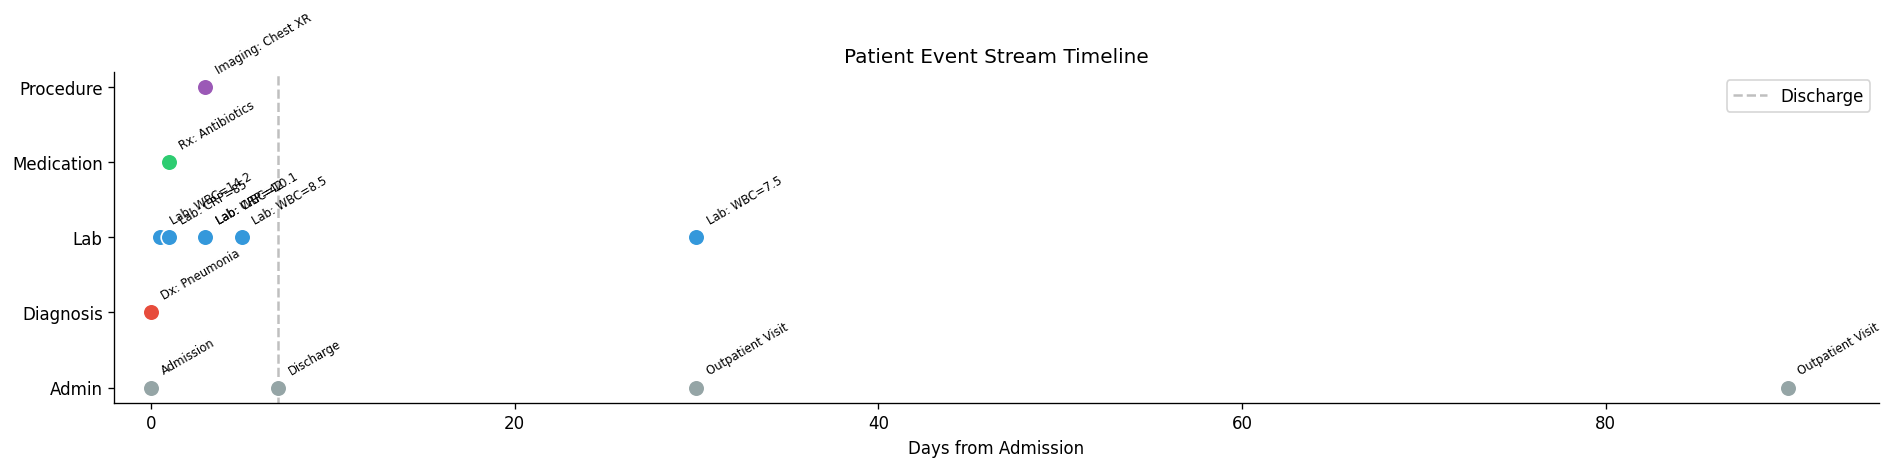

Key observations:
  - Events cluster around admission (many events in days 0-7)
  - Long gaps between outpatient visits (day 7 -> 30 -> 90)
  - Different event types interleave (labs, meds, procedures)
  - This irregular structure cannot be handled by regular time series models


In [3]:
# -- Visualize what an event stream looks like ----------------------------------------
events = [
    (0, 'Admission', 'admin'),
    (0, 'Dx: Pneumonia', 'diagnosis'),
    (0.5, 'Lab: WBC=14.2', 'lab'),
    (1, 'Rx: Antibiotics', 'medication'),
    (1, 'Lab: CRP=85', 'lab'),
    (3, 'Lab: WBC=10.1', 'lab'),
    (3, 'Lab: CRP=42', 'lab'),
    (3, 'Imaging: Chest XR', 'procedure'),
    (5, 'Lab: WBC=8.5', 'lab'),
    (7, 'Discharge', 'admin'),
    (30, 'Outpatient Visit', 'admin'),
    (30, 'Lab: WBC=7.5', 'lab'),
    (90, 'Outpatient Visit', 'admin'),
]

colors = {'admin': '#95a5a6', 'diagnosis': '#e74c3c', 'lab': '#3498db',
          'medication': '#2ecc71', 'procedure': '#9b59b6'}

fig, ax = plt.subplots(figsize=(16, 4))

for day, event_name, event_type in events:
    y_pos = {'admin': 0, 'diagnosis': 1, 'lab': 2, 'medication': 3, 'procedure': 4}[event_type]
    ax.scatter(day, y_pos, c=colors[event_type], s=100, zorder=3, edgecolors='white')
    ax.annotate(event_name, (day, y_pos), textcoords="offset points",
                xytext=(5, 8), fontsize=7, rotation=30)

ax.set_yticks([0, 1, 2, 3, 4])
ax.set_yticklabels(['Admin', 'Diagnosis', 'Lab', 'Medication', 'Procedure'])
ax.set_xlabel('Days from Admission')
ax.set_title('Patient Event Stream Timeline')
ax.axvline(7, color='gray', ls='--', alpha=0.5, label='Discharge')
ax.legend()
ax.set_xlim(-2, 95)

plt.tight_layout()
plt.show()

print("Key observations:")
print("  - Events cluster around admission (many events in days 0-7)")
print("  - Long gaps between outpatient visits (day 7 -> 30 -> 90)")
print("  - Different event types interleave (labs, meds, procedures)")
print("  - This irregular structure cannot be handled by regular time series models")

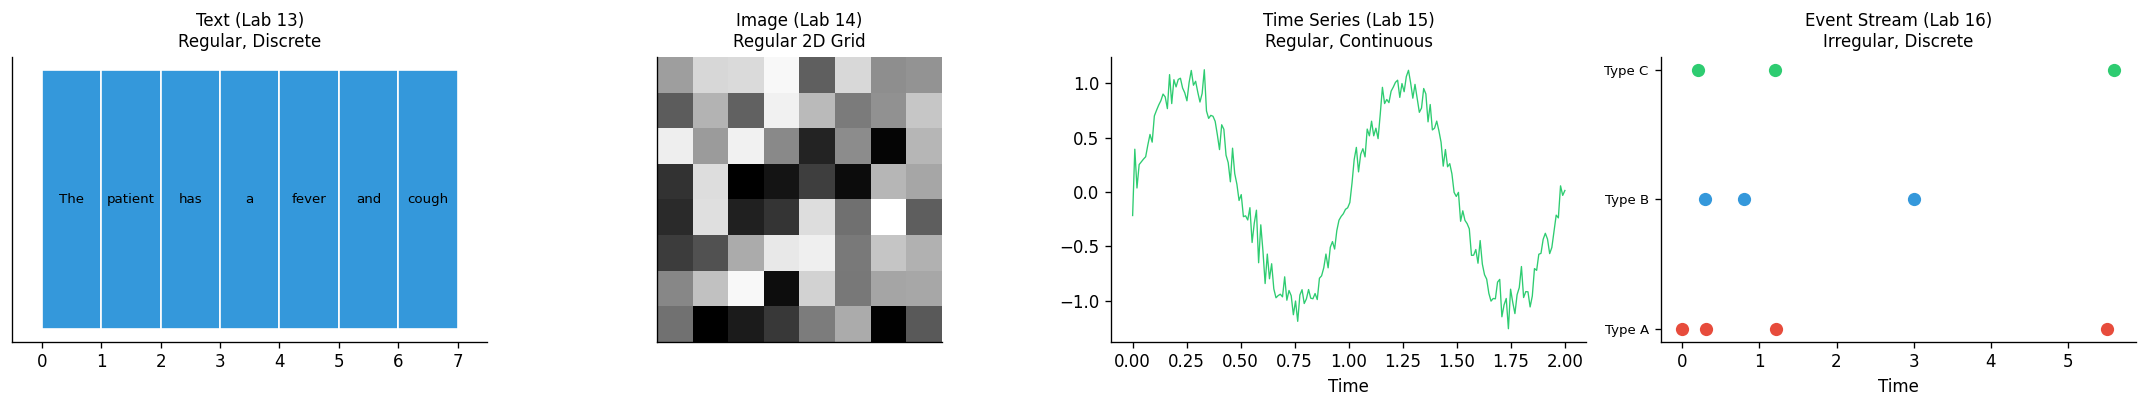

In [4]:
# -- Compare event streams to other modalities ----------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))

# Text: regular discrete tokens
tokens = ['The', 'patient', 'has', 'a', 'fever', 'and', 'cough']
for i, tok in enumerate(tokens):
    axes[0].barh(0, 1, left=i, color='#3498db', edgecolor='white', height=0.5)
    axes[0].text(i + 0.5, 0, tok, ha='center', va='center', fontsize=8)
axes[0].set_title('Text (Lab 13)\nRegular, Discrete', fontsize=10)
axes[0].set_xlim(-0.5, len(tokens) + 0.5)
axes[0].set_yticks([])

# Image: regular 2D grid
img = np.random.rand(8, 8)
axes[1].imshow(img, cmap='gray')
axes[1].set_title('Image (Lab 14)\nRegular 2D Grid', fontsize=10)
axes[1].set_xticks([]); axes[1].set_yticks([])

# Time series: regular continuous
t = np.linspace(0, 2, 200)
axes[2].plot(t, np.sin(2 * np.pi * t) + 0.1 * np.random.randn(200), color='#2ecc71', lw=0.8)
axes[2].set_title('Time Series (Lab 15)\nRegular, Continuous', fontsize=10)
axes[2].set_xlabel('Time')

# Event stream: irregular discrete
event_times = [0, 0.2, 0.3, 0.31, 0.8, 1.2, 1.21, 3.0, 5.5, 5.6]
event_cats = [1, 3, 2, 1, 2, 3, 1, 2, 1, 3]
for t_e, cat in zip(event_times, event_cats):
    axes[3].scatter(t_e, cat, c=['', '#e74c3c', '#3498db', '#2ecc71'][cat],
                   s=80, edgecolors='white', zorder=3)
axes[3].set_title('Event Stream (Lab 16)\nIrregular, Discrete', fontsize=10)
axes[3].set_xlabel('Time')
axes[3].set_yticks([1, 2, 3])
axes[3].set_yticklabels(['Type A', 'Type B', 'Type C'], fontsize=8)

plt.tight_layout()
plt.show()

### 🤔 Reflection 1.1 — Event Streams vs. Other Modalities

1. In text (Lab 13), the distance between adjacent tokens is always 1 position. In event
   streams, the time between consecutive events varies from seconds to months. Why does
   this make standard RNNs and 1D CNNs (designed for regular sequences) poorly suited
   for event streams?

2. Event streams resemble text in that both are sequences of categorical items. But event
   streams additionally carry timestamps and numerical values. How does this extra
   information change the representation challenge?

3. The "missing data is informative" property is unique to clinical event streams. If a
   patient has no lab tests for 6 months, a clinician interprets this as "the patient was
   probably healthy." How would you encode this absence-of-evidence in a feature vector?

4. MEDS uses **string codes** like `"LAB//51301//K/uL"` rather than integer indices. The
   hierarchical `//`-delimited structure encodes source, item ID, and units. How could you
   exploit this hierarchy in a model (e.g., by sharing embeddings at different levels)?

In [5]:
# == SOLUTION -- Reflection 1.1 ===================================================
# 1. Standard RNNs and 1D CNNs assume fixed time intervals between steps. They
#    process position 1, 2, 3, ... with no concept of "how much time elapsed between
#    steps." If we feed events chronologically, the model treats an event 5 minutes
#    after the previous one identically to an event 5 months later. This loses
#    critical temporal information. Solutions: (a) encode elapsed time as an input
#    feature, (b) use time-aware architectures (Time-LSTM, temporal attention),
#    (c) use continuous-time models (Neural ODEs, temporal point processes).
#
# 2. Text tokens are purely categorical -- "fever" is just an index into a vocabulary.
#    Event streams have three components: the code (categorical, needs embedding),
#    the timestamp (continuous, needs temporal encoding), and optionally a value
#    (continuous, needs normalization). The representation must fuse these three
#    heterogeneous types into a single vector per event.
#
# 3. Approaches to encode absence: (a) compute time-since-last-event for each event
#    type as a feature (long gaps = likely healthy), (b) include "observation density"
#    features (events per month), (c) explicitly discretize time into bins and mark
#    bins with no events, (d) use a decay function that explicitly models the absence
#    of events (e.g., exponential decay of "concern" over time).
#
# 4. The MEDS hierarchical code structure (e.g., "LAB//51301//K/uL") can be exploited
#    via: (a) multi-level embeddings (embed "LAB" at a category level, "51301" at an
#    item level, compose them), (b) code grouping (collapse codes at a coarser level
#    like "LAB//" prefix for reduced dimensionality), (c) parent-code embeddings
#    using the `parent_codes` field in MEDS metadata. This is similar to how subword
#    tokenization helps handle rare words in NLP.

---
## Part 2 — Loading and Exploring Real MEDS Data

We load the **MIMIC-IV demo** dataset in MEDS format. This contains de-identified EHR data
for **100 ICU patients** — real diagnoses, labs, medications, procedures, and vitals.

The dataset comes pre-split into `train/` (80 patients), `tuning/` (10), and `held_out/` (10).

Our prediction task is **short ICU length-of-stay**: given events up to 24h after ICU admission,
predict whether the patient will be discharged from ICU within 3 days.

In [6]:
# -- Load MEDS data and labels -------------------------------------------------------
data_root = Path("MEDS_data/data")
labels_root = Path("MEDS_data/labels/short_LOS")
metadata_root = Path("MEDS_data/metadata")

# Load all splits
train_data_raw = pd.read_parquet(data_root / "train")[["subject_id", "time", "code", "numeric_value", "text_value"]]
val_data_raw = pd.read_parquet(data_root / "tuning")[["subject_id", "time", "code", "numeric_value", "text_value"]]
test_data_raw = pd.read_parquet(data_root / "held_out")[["subject_id", "time", "code", "numeric_value", "text_value"]]

# Load labels
train_labels = pd.read_parquet(labels_root / "train")[["subject_id", "prediction_time", "boolean_value"]]
val_labels = pd.read_parquet(labels_root / "tuning")[["subject_id", "prediction_time", "boolean_value"]]
test_labels = pd.read_parquet(labels_root / "held_out")[["subject_id", "prediction_time", "boolean_value"]]

print("=== MEDS Data Loaded ===")
print(f"Train data: {len(train_data_raw):,} events across {train_data_raw['subject_id'].nunique()} patients")
print(f"Val data:   {len(val_data_raw):,} events across {val_data_raw['subject_id'].nunique()} patients")
print(f"Test data:  {len(test_data_raw):,} events across {test_data_raw['subject_id'].nunique()} patients")
print(f"\nTrain labels: {len(train_labels)} samples | Positive rate: {train_labels['boolean_value'].mean():.3f}")
print(f"Val labels:   {len(val_labels)} samples | Positive rate: {val_labels['boolean_value'].mean():.3f}")
print(f"Test labels:  {len(test_labels)} samples | Positive rate: {test_labels['boolean_value'].mean():.3f}")

print("\n--- Sample MEDS events (first patient) ---")
sample_id = train_data_raw['subject_id'].iloc[0]
display(train_data_raw[train_data_raw['subject_id'] == sample_id].head(15))

FileNotFoundError: [Errno 2] No such file or directory: 'MEDS_data/data/train'

In [7]:
# -- Inspect MEDS metadata -----------------------------------------------------------
codes_metadata = pd.read_parquet(metadata_root / "codes.parquet")
print(f"Code vocabulary size: {len(codes_metadata)} unique codes")
print("\nSample codes with descriptions:")
display(codes_metadata.head(10))

# Look at code prefixes to understand the data categories
code_prefixes = train_data_raw['code'].str.split("//").str[0]
prefix_counts = code_prefixes.value_counts()
print("\nEvent type distribution (by code prefix):")
for prefix, count in prefix_counts.head(15).items():
    print(f"  {prefix:30s}  {count:>6,} events")

print(f"\n  Dataset JSON:")
import json
ds_meta = json.loads((metadata_root / "dataset.json").read_text())
for k, v in ds_meta.items():
    print(f"    {k}: {v}")

FileNotFoundError: [Errno 2] No such file or directory: 'MEDS_data/metadata/codes.parquet'

In [8]:
# -- Build patient event lists from MEDS data ----------------------------------------
# For each labeled sample, we extract the patient's events up to the prediction time.
# We then convert to a format compatible with our downstream models.

# Build a code vocabulary (map string codes to integer indices)
all_codes = pd.concat([train_data_raw['code'], val_data_raw['code'], test_data_raw['code']]).unique()
CODE_TO_IDX = {code: idx + 1 for idx, code in enumerate(sorted(all_codes))}  # 0 reserved for padding
IDX_TO_CODE = {v: k for k, v in CODE_TO_IDX.items()}
VOCAB_SIZE = len(CODE_TO_IDX)
print(f"Vocabulary: {VOCAB_SIZE} unique codes (+ padding index 0)")

# Assign coarse categories based on MEDS code prefixes
def get_category(code):
    prefix = code.split("//")[0]
    cat_map = {
        'DIAGNOSIS': 'Diagnosis', 'PROCEDURE': 'Procedure', 'LAB': 'Lab',
        'PRESCRIPTION': 'Medication', 'GENDER': 'Demographics', 'MEDS_BIRTH': 'Demographics',
        'MEDS_DEATH': 'Admin', 'HOSPITAL_ADMISSION': 'Admin', 'HOSPITAL_DISCHARGE': 'Admin',
        'ICU_ADMISSION': 'Admin', 'ICU_DISCHARGE': 'Admin', 'INSURANCE': 'Demographics',
    }
    return cat_map.get(prefix, 'Other')

CODE_CATEGORIES = {code: get_category(code) for code in all_codes}

def build_patient_samples(data_df, labels_df):
    """Build patient event lists from MEDS DataFrames.

    For each label row, we extract events up to prediction_time and convert
    timestamps to relative days from the first event.
    """
    patients = []
    for _, label_row in labels_df.iterrows():
        sid = label_row['subject_id']
        pred_time = label_row['prediction_time']
        label = int(label_row['boolean_value'])

        # Get events for this patient up to prediction time
        mask = (data_df['subject_id'] == sid) & (data_df['time'] <= pred_time)
        patient_events = data_df[mask].sort_values('time')

        if len(patient_events) == 0:
            continue

        # Convert to relative days from first event
        t0 = patient_events['time'].min()
        events = []
        for _, row in patient_events.iterrows():
            time_days = (row['time'] - t0).total_seconds() / 86400.0
            code_idx = CODE_TO_IDX[row['code']]
            value = row['numeric_value'] if pd.notna(row['numeric_value']) else np.nan
            events.append((time_days, code_idx, value))

        patients.append({
            'patient_id': sid,
            'events': events,
            'label': label,
            'n_events': len(events),
        })
    return patients

print("Building patient event lists...")
train_patients = build_patient_samples(train_data_raw, train_labels)
val_patients = build_patient_samples(val_data_raw, val_labels)
test_patients = build_patient_samples(test_data_raw, test_labels)

y_train = np.array([p['label'] for p in train_patients])
y_val = np.array([p['label'] for p in val_patients])
y_test = np.array([p['label'] for p in test_patients])

print(f"\nTrain: {len(train_patients)} samples | Short LOS rate: {y_train.mean():.3f}")
print(f"Val:   {len(val_patients)} samples | Short LOS rate: {y_val.mean():.3f}")
print(f"Test:  {len(test_patients)} samples | Short LOS rate: {y_test.mean():.3f}")

lengths = [p['n_events'] for p in train_patients]
print(f"\nEvents per sample: mean={np.mean(lengths):.0f}, "
      f"median={np.median(lengths):.0f}, min={np.min(lengths)}, max={np.max(lengths)}")

NameError: name 'train_data_raw' is not defined

NameError: name 'train_patients' is not defined

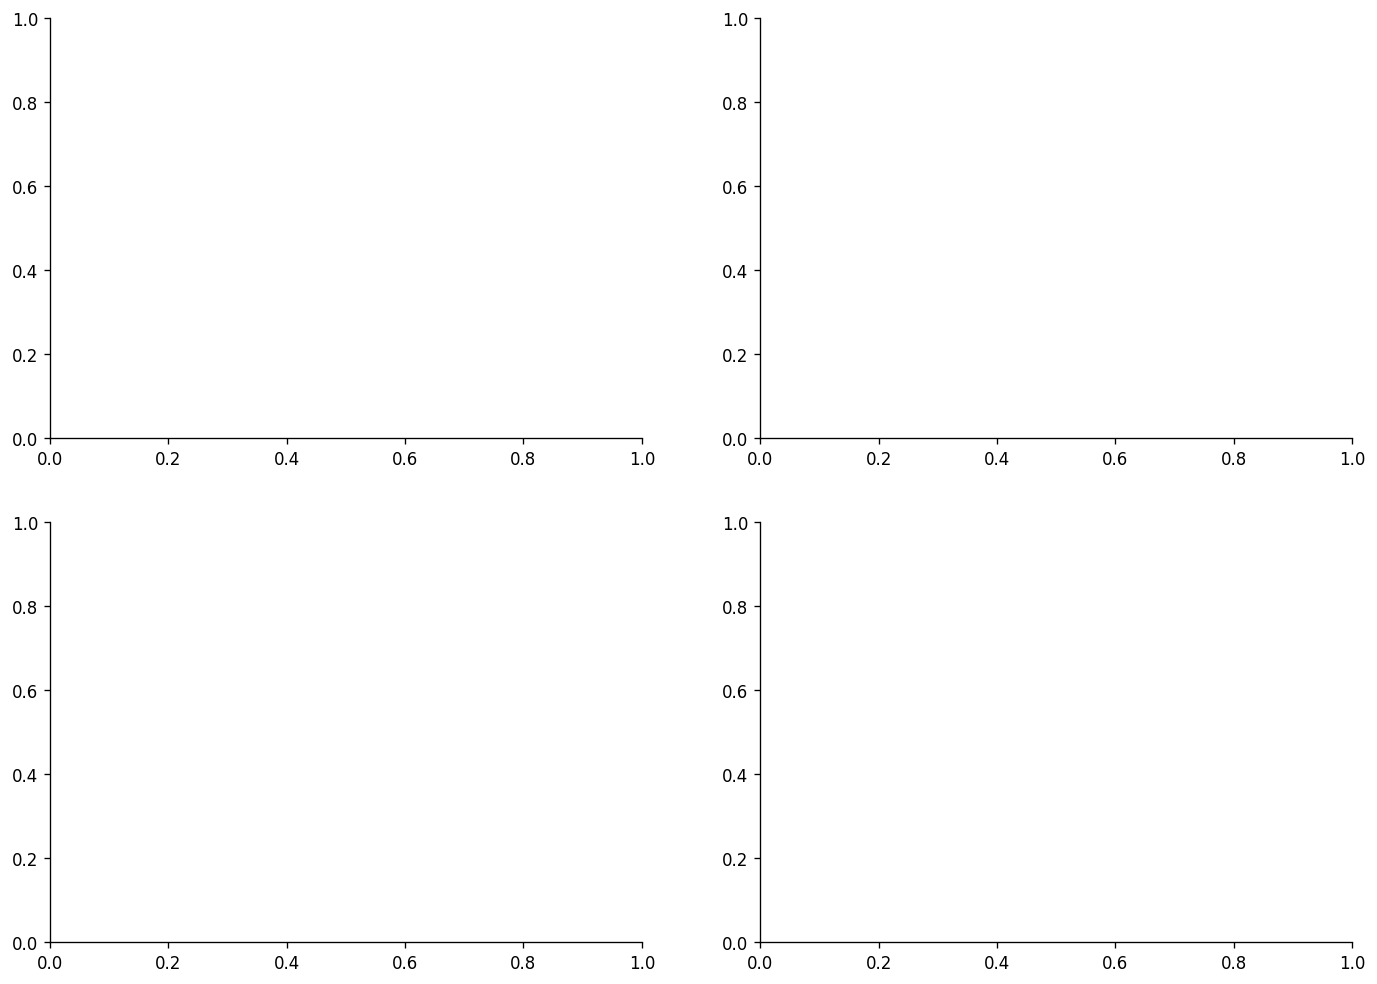

In [9]:
# -- Explore the data ---------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Events per patient histogram
lengths = [p['n_events'] for p in train_patients]
axes[0, 0].hist(lengths, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[0, 0].set_xlabel('Number of Events')
axes[0, 0].set_ylabel('Number of Samples')
axes[0, 0].set_title('Events per Patient Sample')
axes[0, 0].axvline(np.median(lengths), color='#e74c3c', ls='--',
                   label=f'Median: {np.median(lengths):.0f}')
axes[0, 0].legend()

# 2. Event type distribution
all_codes_train = [IDX_TO_CODE[e[1]] for p in train_patients for e in p['events']]
cat_counts = Counter([CODE_CATEGORIES.get(c, 'Other') for c in all_codes_train])
cats = list(cat_counts.keys())
cat_vals = [cat_counts[c] for c in cats]
cat_colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#95a5a6', '#f39c12', '#1abc9c']
axes[0, 1].barh(cats, cat_vals, color=cat_colors[:len(cats)], edgecolor='white')
axes[0, 1].set_xlabel('Total Events (train set)')
axes[0, 1].set_title('Event Type Distribution (MIMIC-IV MEDS)')

# 3. Inter-event time distribution
all_gaps = []
for p in train_patients:
    times = sorted([e[0] for e in p['events']])
    gaps = np.diff(times)
    all_gaps.extend(gaps[gaps > 0])
if all_gaps:
    axes[1, 0].hist(all_gaps, bins=100, color='#2ecc71', edgecolor='white', alpha=0.8,
                   range=(0, min(30, max(all_gaps))))
    axes[1, 0].set_xlabel('Days Between Consecutive Events')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('Inter-Event Time Distribution')
    axes[1, 0].axvline(np.median(all_gaps), color='#e74c3c', ls='--',
                       label=f'Median: {np.median(all_gaps):.3f} days')
    axes[1, 0].legend()

# 4. Events per patient by label
neg_lens = [p['n_events'] for p in train_patients if p['label'] == 0]
pos_lens = [p['n_events'] for p in train_patients if p['label'] == 1]
bp = axes[1, 1].boxplot([neg_lens, pos_lens], labels=['Long LOS', 'Short LOS'],
                        patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1, 1].set_ylabel('Number of Events')
axes[1, 1].set_title('Events per Sample by Label')

plt.tight_layout()
plt.show()

print("\nNote: This is REAL clinical data from MIMIC-IV, not synthetic data!")
print("The event distribution reflects actual ICU care patterns.")

### 🤔 Reflection 2.1 — Understanding Real MEDS Event Stream Properties

1. The number of events per patient varies enormously. Sicker patients tend to have MORE
   events (more labs, more medications). This means sequence length is **correlated with the
   outcome**. How could a model exploit this spuriously? How would you control for it?

2. Look at the inter-event time distribution. Most gaps are short (clustered events during
   ICU stays), but some are very long (months between outpatient visits). Why is this
   bimodal distribution challenging for models that process sequences one event at a time?

3. Compare the code vocabulary here (1,000+ codes in the MIMIC-IV MEDS demo) to our
   simple text vocabularies in Lab 13 (30,000 subword tokens in BERT). What are the
   similarities and differences in how these vocabularies should be handled?

4. MEDS stores data as Parquet files partitioned by split (`train/`, `tuning/`, `held_out/`).
   Why is this pre-splitting important for reproducible ML research in healthcare?

In [10]:
# == SOLUTION -- Reflection 2.1 ===================================================
# 1. The simplest (but spurious) predictor would be: "more events = sicker = more
#    likely to have a long LOS." This is CONFOUNDING BY INDICATION -- the act of
#    being observed is correlated with the outcome. Controls: (a) include event count
#    as a feature and verify the model uses other features too, (b) evaluate within
#    strata of event count, (c) use a model that attends to event content not just count.
#
# 2. The bimodal distribution means the model must handle two very different temporal
#    regimes: (a) rapid sequences during acute care (events minutes apart), and (b)
#    sparse sequences during chronic care (events months apart). A fixed-step RNN
#    either over-processes the gaps or under-processes the bursts
#
# 3. EHR vocabulary (~1,000 codes here, ~10K-70K in full MIMIC) is similar in size to
#    text vocabularies but much sparser per patient. A single patient might use <100
#    unique codes. Solutions: code grouping (e.g., using parent_codes from MEDS metadata),
#    frequency filtering, or pre-trained code embeddings.
#
# 4. Pre-defined splits prevent data leakage and enable exact reproducibility. Every
#    researcher using MEDS MIMIC-IV demo gets the same 80/10/10 split. Without this,
#    different random splits make results incomparable — a core problem MEDS solves.

---
## Part 3 — Baseline: Tabularizing Event Streams

Converting an event stream to a fixed-length vector requires discarding temporal structure
while retaining as much information as possible. Standard approaches:

### Approach A — Count Features
For each event code, count how many times it appears in the patient's history.
This produces a sparse count vector (analogous to Bag-of-Words for text).

### Approach B — Enriched Features
Go beyond simple counts:
- Code counts (Bag-of-Events)
- Temporal features: total span, event density, recency of each code
- Statistical features from lab values: mean, last, min, max, trend
- Interaction features: number of unique codes, code diversity

Note: In a real MEDS workflow, the **MEDS-Tab** tool automates this tabularization
process with sophisticated feature engineering. Here we implement it manually for
pedagogical purposes.

In [11]:
# This is an exercise cell with TODOs (??? placeholders) for student work.
# It is skipped in the book build to keep downstream cells runnable.
# Open the notebook in Colab to complete the exercise:
# Exercise cell skipped in book build
print("[exercise cell skipped — open in Colab to complete the TODOs]")


[exercise cell skipped — open in Colab to complete the TODOs]


In [12]:
# == SOLUTION -- tabularize_patient =================================================
def tabularize_patient(patient, vocab_size=VOCAB_SIZE):
    events = patient['events']

    code_counts = np.zeros(vocab_size + 1)
    for time, code_idx, value in events:
        code_counts[code_idx] += 1

    times = [e[0] for e in events]
    total_span = max(times) - min(times) if len(times) > 1 else 0
    events_per_day = len(events) / (total_span + 1)
    time_since_last = max(times) - min(times) if len(times) > 1 else 0

    lab_means = np.zeros(vocab_size + 1)
    lab_lasts = np.zeros(vocab_size + 1)
    lab_counts = np.zeros(vocab_size + 1)
    for time, code_idx, value in events:
        if not np.isnan(value):
            lab_counts[code_idx] += 1
            lab_means[code_idx] += value
            lab_lasts[code_idx] = value

    for i in range(vocab_size + 1):
        if lab_counts[i] > 0:
            lab_means[i] /= lab_counts[i]

    total_events = len(events)
    unique_codes = len(set(e[1] for e in events))

    features = np.concatenate([
        code_counts,
        [total_span, events_per_day, time_since_last],
        lab_means, lab_lasts,
        [total_events, unique_codes],
    ])
    return features

test_feat = tabularize_patient(train_patients[0])
print(f"Feature vector length: {len(test_feat)}")
print(f"Code counts (first 10 nonzero):")
nonzero = np.nonzero(test_feat[:VOCAB_SIZE+1])[0][:10]
for idx in nonzero:
    print(f"  {IDX_TO_CODE.get(idx, 'PAD'):50s}  count={test_feat[idx]:.0f}")

NameError: name 'VOCAB_SIZE' is not defined

In [13]:
# -- Build tabular datasets and train baselines ------------------------------------
print("Tabularizing event streams...")
X_train_tab = np.array([tabularize_patient(p) for p in train_patients])
X_val_tab = np.array([tabularize_patient(p) for p in val_patients])
X_test_tab = np.array([tabularize_patient(p) for p in test_patients])
print(f"Feature matrix shape: {X_train_tab.shape}")

# Handle NaN/Inf
X_train_tab = np.nan_to_num(X_train_tab, nan=0, posinf=0, neginf=0)
X_val_tab = np.nan_to_num(X_val_tab, nan=0, posinf=0, neginf=0)
X_test_tab = np.nan_to_num(X_test_tab, nan=0, posinf=0, neginf=0)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_tab)
X_val_s = scaler.transform(X_val_tab)
X_test_s = scaler.transform(X_test_tab)

print("\n=== Tabularization Baselines ===\n")
tab_models = {
    'LR + Tabular': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'RF + Tabular': RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42),
    'GBT + Tabular': GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42),
}
tab_results = {}
for name, model in tab_models.items():
    model.fit(X_train_s, y_train)
    # Use val if enough samples, else report train
    if len(y_val) > 1 and len(np.unique(y_val)) > 1:
        val_proba = model.predict_proba(X_val_s)[:, 1]
        val_auc = roc_auc_score(y_val, val_proba)
    else:
        val_proba = model.predict_proba(X_train_s)[:, 1]
        val_auc = roc_auc_score(y_train, val_proba)
    tab_results[name] = {'model': model, 'val_auc': val_auc}
    print(f"  {name:25s}  Val AUROC = {val_auc:.4f}")

print("\nNote: Small dataset (demo has only ~100 patients) means high variance.")
print("In practice, MEDS enables running the same pipeline on the full MIMIC-IV (~70K patients).")

Tabularizing event streams...


NameError: name 'train_patients' is not defined

In [14]:
# -- Feature importance from GBT ----------------------------------------------------
best_tab_name = max(tab_results, key=lambda k: tab_results[k]['val_auc'])
best_tab = tab_results[best_tab_name]['model']

if hasattr(best_tab, 'feature_importances_'):
    # Build feature names
    feat_names = (
        [IDX_TO_CODE.get(i, f'code_{i}') for i in range(VOCAB_SIZE + 1)]
        + ['span', 'density', 'recency']
        + [f'lab_mean_{IDX_TO_CODE.get(i, i)}' for i in range(VOCAB_SIZE + 1)]
        + [f'lab_last_{IDX_TO_CODE.get(i, i)}' for i in range(VOCAB_SIZE + 1)]
        + ['total_events', 'unique_codes']
    )
    importances = best_tab.feature_importances_
    top_idx = np.argsort(importances)[-15:]

    # Shorten names for display
    short_names = []
    for i in top_idx:
        name = feat_names[i] if i < len(feat_names) else f'feat_{i}'
        if len(name) > 40:
            name = name[:37] + '...'
        short_names.append(name)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(short_names, importances[top_idx], color='#3498db')
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 15 Features ({best_tab_name})')
    plt.tight_layout()
    plt.show()

NameError: name 'tab_results' is not defined

### 🤔 Reflection 3.1 — Tabularization Trade-offs

1. Our Bag-of-Events approach counts code occurrences — exactly like Bag-of-Words for
   text. What temporal information is lost? Give a concrete clinical example where the
   ORDER of events matters for predicting ICU discharge.

2. We included lab *values* (mean, last) in addition to code counts. Why are these
   important? A patient with "LAB//51301" (WBC) appearing 10 times could have stable
   values or a rapidly worsening trend. How does our feature set distinguish these?

3. In a real MEDS workflow, you would use the **MEDS-Tab** package to automate
   tabularization with sophisticated windowed aggregations. What advantages does an
   automated approach have over hand-crafted features?

4. Our vocabulary has ~1,000 codes from the demo. Full MIMIC-IV has ~30,000 codes.
   How would you handle this in practice?

In [15]:
# == SOLUTION -- Reflection 3.1 ===================================================
# 1. Bag-of-Events loses: (a) the ORDER of events -- improving vs worsening vital
#    signs look identical as counts. (b) TIMING -- rapid deterioration (5 abnormal
#    labs in 2 hours) vs gradual change (5 labs over 5 days) produce same counts.
#    Example: rising creatinine (1.0->2.0->3.0) strongly predicts prolonged LOS,
#    but the count of creatinine labs doesn't capture the TREND.
#
# 2. Lab values are critical: "WBC = 7.0" is normal while "WBC = 25.0" suggests
#    severe infection. Our features partially capture this via mean and last, but
#    miss trends. Adding slope features (last - first / time span) would help.
#
# 3. MEDS-Tab advantages: (a) automated feature engineering with configurable time
#    windows, (b) handles the full code vocabulary efficiently via sparse matrices,
#    (c) consistent reproducible features across datasets, (d) integrates with the
#    broader MEDS ecosystem for benchmarking via MEDS-DEV.
#
# 4. For large vocabularies: (a) use MEDS parent_codes to group codes hierarchically,
#    (b) frequency filtering (drop codes in <1% of patients), (c) dimensionality
#    reduction (PCA/SVD on sparse count matrix), (d) embedding-based approaches.

---
## Part 4 — Temporal Embeddings: Encoding What, When, and How Much

To feed event streams into neural networks, we need to represent each event as a dense vector
that captures three pieces of information:

1. **What** happened: the event code $\to$ learned embedding (like word embeddings in Lab 13)
2. **When** it happened: the timestamp $\to$ temporal encoding
3. **How much** (optional): the value $\to$ linear projection

### Temporal Encoding

Unlike text (where position is an integer index), event timestamps are continuous and
irregularly spaced. We use a **time2vec** approach with sinusoidal encodings:

$$\text{TimeEnc}(t) = [\sin(\omega_1 t + \phi_1), \cos(\omega_1 t + \phi_1), \ldots, \sin(\omega_d t + \phi_d), \cos(\omega_d t + \phi_d)]$$

where $\omega_i$ and $\phi_i$ are learnable frequencies and phases.

### Final Event Representation

$$\mathbf{e}_i = \text{CodeEmbed}(c_i) + \text{TimeEnc}(t_i) + \text{ValueProj}(v_i)$$

In [16]:
# This is an exercise cell with TODOs (??? placeholders) for student work.
# It is skipped in the book build to keep downstream cells runnable.
# Open the notebook in Colab to complete the exercise:
# Exercise cell skipped in book build
print("[exercise cell skipped — open in Colab to complete the TODOs]")


[exercise cell skipped — open in Colab to complete the TODOs]


In [17]:
# == SOLUTION -- TemporalEncoding ===================================================
class TemporalEncoding(nn.Module):
    def __init__(self, d_model, max_freqs=16):
        super().__init__()
        self.freqs = nn.Parameter(torch.randn(max_freqs) * 0.1)
        self.phases = nn.Parameter(torch.zeros(max_freqs))
        self.proj = nn.Linear(max_freqs * 2, d_model)

    def forward(self, timestamps):
        t = timestamps.unsqueeze(-1)
        angles = t * self.freqs + self.phases
        sin_feats = torch.sin(angles)
        cos_feats = torch.cos(angles)
        time_feats = torch.cat([sin_feats, cos_feats], dim=-1)
        return self.proj(time_feats)

te = TemporalEncoding(d_model=64)
t_test = torch.tensor([[0.0, 1.0, 3.0, 30.0, 90.0]])
enc = te(t_test)
print(f"Input timestamps shape: {t_test.shape}")
print(f"Output encoding shape: {enc.shape}")

Input timestamps shape: torch.Size([1, 5])
Output encoding shape: torch.Size([1, 5, 64])


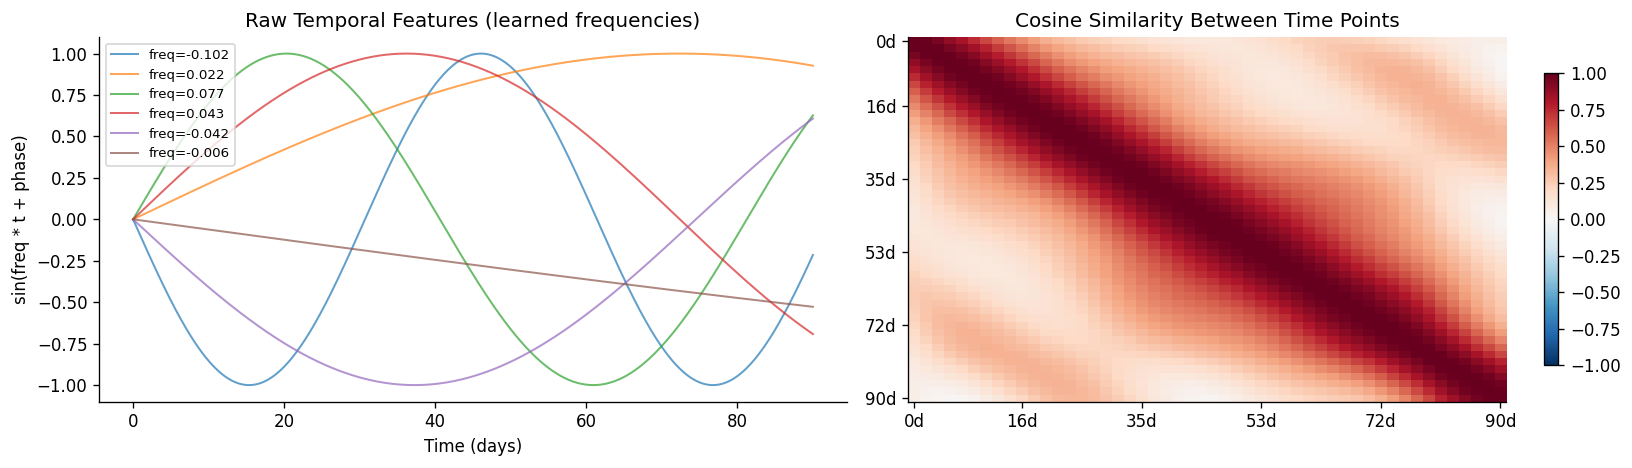

Nearby time points have similar encodings; distant points differ.
The model LEARNS which time scales matter for the prediction task.


In [18]:
# -- Visualize temporal encodings ---------------------------------------------------
te_vis = TemporalEncoding(d_model=64, max_freqs=16)
t_range = torch.linspace(0, 90, 500).unsqueeze(0)

with torch.no_grad():
    enc_vis = te_vis(t_range)
    t_exp = t_range.unsqueeze(-1)
    angles = t_exp * te_vis.freqs + te_vis.phases
    raw_sin = torch.sin(angles)[0].numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i in range(min(6, raw_sin.shape[1])):
    axes[0].plot(t_range[0].numpy(), raw_sin[:, i], alpha=0.7, lw=1.2,
                label=f'freq={te_vis.freqs[i].item():.3f}')
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('sin(freq * t + phase)')
axes[0].set_title('Raw Temporal Features (learned frequencies)')
axes[0].legend(fontsize=8)

enc_np = enc_vis[0].detach().numpy()
sim = enc_np @ enc_np.T
sim /= (np.linalg.norm(enc_np, axis=1, keepdims=True) @
        np.linalg.norm(enc_np, axis=1, keepdims=True).T + 1e-8)
sub_idx = np.linspace(0, 499, 50).astype(int)
sub_sim = sim[np.ix_(sub_idx, sub_idx)]
sub_times = t_range[0][sub_idx].numpy()

im = axes[1].imshow(sub_sim, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
tick_pos = np.linspace(0, 49, 6).astype(int)
axes[1].set_xticks(tick_pos); axes[1].set_xticklabels([f'{sub_times[i]:.0f}d' for i in tick_pos])
axes[1].set_yticks(tick_pos); axes[1].set_yticklabels([f'{sub_times[i]:.0f}d' for i in tick_pos])
axes[1].set_title('Cosine Similarity Between Time Points')
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

print("Nearby time points have similar encodings; distant points differ.")
print("The model LEARNS which time scales matter for the prediction task.")

### 🤔 Reflection 4.1 — Temporal Encoding

1. We used learnable sinusoidal encodings. The original Transformer used **fixed**
   sinusoidal positional encodings. Why might learnable frequencies be better for
   clinical time series?

2. The temporal encoding maps a scalar timestamp to a $d$-dimensional vector. This is
   analogous to word embeddings mapping a token ID to a vector. What is the key difference?

3. We added the temporal encoding to the code embedding: $\mathbf{e}_i = \text{CodeEmbed}(c_i)
   + \text{TimeEnc}(t_i)$. What are the alternatives to addition?

4. For our short ICU LOS prediction task, what time scales do you expect the model to learn
   as important? (Think: hours within the first day, vs. days of prior history.)

In [19]:
# == SOLUTION -- Reflection 4.1 ===================================================
# 1. Fixed sinusoidal encodings use frequencies on a geometric scale. But clinical
#    relevance is NOT uniform: events hours apart during an ICU stay have very
#    different significance than events months apart. LEARNABLE frequencies allow
#    the model to focus on clinically relevant time scales.
#
# 2. Word embeddings: discrete input (integer -> lookup). Temporal encoding:
#    continuous input (float -> smooth function). Nearby timestamps map to SIMILAR
#    vectors. This continuity is essential because time is continuous.
#
# 3. Addition is parameter-efficient. CONCATENATION preserves both signals
#    independently but doubles the dimension. Concatenation might be better when
#    code and time information interact in complex ways.
#
# 4. For short ICU LOS prediction: (a) HOURS scale -- for inpatient event timing
#    (when did labs come back? how quickly did vitals stabilize?), (b) ~1 DAY --
#    capturing the 24h prediction window, (c) ~3 DAYS -- the target outcome window.
#    Events from months ago are likely less informative than the acute trajectory.

---
## Part 5 — Transformer for Event Stream Classification

Architecture:
1. **Event embedding**: code embedding + temporal encoding + optional value projection
2. **Transformer encoder**: self-attention layers
3. **Pooling**: masked mean aggregation
4. **Classifier**: linear layer for binary classification

In [20]:
# -- Dataset class for MEDS event streams --------------------------------------------

class EventStreamDataset(Dataset):
    def __init__(self, patients, max_events=256):
        self.patients = patients
        self.max_events = max_events

    def __len__(self):
        return len(self.patients)

    def __getitem__(self, idx):
        p = self.patients[idx]
        events = p['events']

        # Truncate to max_events (keep most recent)
        if len(events) > self.max_events:
            events = events[-self.max_events:]

        codes = torch.tensor([e[1] for e in events], dtype=torch.long)
        times = torch.tensor([e[0] for e in events], dtype=torch.float32)
        values = torch.tensor([0.0 if np.isnan(e[2]) else e[2] for e in events],
                             dtype=torch.float32)
        has_value = torch.tensor([0.0 if np.isnan(e[2]) else 1.0 for e in events],
                                dtype=torch.float32)
        label = torch.tensor(p['label'], dtype=torch.float32)

        return codes, times, values, has_value, label

def collate_event_streams(batch):
    codes, times, values, has_value, labels = zip(*batch)

    codes_padded = pad_sequence(codes, batch_first=True, padding_value=0)
    times_padded = pad_sequence(times, batch_first=True, padding_value=0)
    values_padded = pad_sequence(values, batch_first=True, padding_value=0)
    has_value_padded = pad_sequence(has_value, batch_first=True, padding_value=0)

    lengths = torch.tensor([len(c) for c in codes])
    max_len = codes_padded.shape[1]
    mask = torch.arange(max_len).expand(len(lengths), -1) < lengths.unsqueeze(1)

    labels = torch.stack(labels)

    return codes_padded, times_padded, values_padded, has_value_padded, mask, labels

# Create datasets and loaders
train_ds = EventStreamDataset(train_patients)
val_ds = EventStreamDataset(val_patients)
test_ds = EventStreamDataset(test_patients)

BATCH_SIZE = min(16, len(train_patients))
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_event_streams)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, collate_fn=collate_event_streams)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, collate_fn=collate_event_streams)

# Test batch
codes_b, times_b, values_b, has_val_b, mask_b, labels_b = next(iter(train_dl))
print(f"Batch shapes:")
print(f"  Codes:  {codes_b.shape}")
print(f"  Times:  {times_b.shape}")
print(f"  Values: {values_b.shape}")
print(f"  Mask:   {mask_b.shape}")
print(f"  Labels: {labels_b.shape}")

NameError: name 'train_patients' is not defined

In [21]:
# This is an exercise cell with TODOs (??? placeholders) for student work.
# It is skipped in the book build to keep downstream cells runnable.
# Open the notebook in Colab to complete the exercise:
# Exercise cell skipped in book build
print("[exercise cell skipped — open in Colab to complete the TODOs]")


[exercise cell skipped — open in Colab to complete the TODOs]


In [22]:
# == SOLUTION -- EventStreamTransformer =============================================
class EventStreamTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.d_model = d_model
        self.code_embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.time_enc = TemporalEncoding(d_model, max_freqs=16)
        self.value_proj = nn.Linear(1, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 1),
        )

    def forward(self, codes, times, values, has_value, mask):
        code_emb = self.code_embed(codes)
        time_emb = self.time_enc(times)
        val_emb = self.value_proj(values.unsqueeze(-1)) * has_value.unsqueeze(-1)

        x = code_emb + time_emb + val_emb

        attn_mask = ~mask
        h = self.transformer(x, src_key_padding_mask=attn_mask)

        mask_expanded = mask.unsqueeze(-1).float()
        h_pooled = (h * mask_expanded).sum(dim=1) / mask_expanded.sum(dim=1).clamp(min=1)

        out = torch.sigmoid(self.classifier(h_pooled)).squeeze(-1)
        return out

model = EventStreamTransformer(vocab_size=VOCAB_SIZE + 1, d_model=64)
print(model)
test_out = model(codes_b, times_b, values_b, has_val_b, mask_b)
print(f"\nOutput shape: {test_out.shape}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

NameError: name 'VOCAB_SIZE' is not defined

In [23]:
# -- Training infrastructure -------------------------------------------------------
def train_epoch_es(model, loader, optimizer, criterion):
    model.train()
    total_loss, n = 0, 0
    for codes, times, values, has_val, mask, labels in loader:
        codes, times, values = codes.to(device), times.to(device), values.to(device)
        has_val, mask, labels = has_val.to(device), mask.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(codes, times, values, has_val, mask)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(labels)
        n += len(labels)
    return total_loss / n

@torch.no_grad()
def evaluate_es(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss, n = 0, 0
    criterion = nn.BCELoss()
    for codes, times, values, has_val, mask, labels in loader:
        codes, times, values = codes.to(device), times.to(device), values.to(device)
        has_val, mask, labels = has_val.to(device), mask.to(device), labels.to(device)
        out = model(codes, times, values, has_val, mask)
        total_loss += criterion(out, labels).item() * len(labels)
        all_preds.append(out.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        n += len(labels)
    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    # Handle edge case where only one class is present
    if len(np.unique(labels)) < 2:
        auc = 0.5
    else:
        auc = roc_auc_score(labels, preds)
    return auc, total_loss / n, preds, labels

In [24]:
# -- Train the Transformer ---------------------------------------------------------
print("=" * 60)
print("Training Event Stream Transformer on MIMIC-IV MEDS Data")
print("=" * 60)

model = EventStreamTransformer(vocab_size=VOCAB_SIZE + 1, d_model=64,
                                nhead=4, num_layers=2, dropout=0.2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCELoss()

history = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}
best_val_auc, best_state, wait = 0, None, 0
PATIENCE = 10

for epoch in range(1, 51):
    train_loss = train_epoch_es(model, train_dl, optimizer, criterion)
    train_auc, _, _, _ = evaluate_es(model, train_dl)
    val_auc, val_loss, _, _ = evaluate_es(model, val_dl)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:2d} | Train Loss: {train_loss:.4f} | "
              f"Train AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f} | Best: {best_val_auc:.4f}")

    if wait >= PATIENCE:
        print(f"  Early stopping at epoch {epoch}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history['train_loss'], label='Train', color='#3498db')
axes[0].plot(history['val_loss'], label='Val', color='#e74c3c')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Transformer -- Loss Curves'); axes[0].legend()
axes[1].plot(history['train_auc'], label='Train', color='#3498db')
axes[1].plot(history['val_auc'], label='Val', color='#e74c3c')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUROC')
axes[1].set_title('Transformer -- AUROC Curves'); axes[1].legend()
plt.tight_layout()
plt.show()

Training Event Stream Transformer on MIMIC-IV MEDS Data


NameError: name 'VOCAB_SIZE' is not defined

### 🤔 Reflection 5.1 — Transformers for Event Streams

1. We used `code_emb + time_emb + val_emb` to combine three information sources. This
   means all three must live in the same $d$-dimensional space. What are the risks?

2. Self-attention considers ALL $L^2$ event pairs. For $L=256$, that's 65,536 pairs.
   What is the computational cost, and when does this become prohibitive?

3. We used masked mean pooling. Why is masking particularly important for event streams
   (compared to images or text)?

4. Our model has ~120K parameters trained on ~80 patients. Compare this ratio to BERT
   (110M parameters pre-trained on billions of words). Why might event stream models
   benefit MORE from pre-training than from architectural improvements?

In [25]:
# == SOLUTION -- Reflection 5.1 ===================================================
# 1. Shared space risks: interference between temporal and code signals, and
#    capacity limitation (d=64 must encode code identity, time position, AND lab
#    values). Mitigation: increase d_model, or concatenate instead of add.
#
# 2. Cost is O(L^2 * d). For L=256, manageable. For L=5000 (long patient histories),
#    this becomes prohibitive and requires sparse attention or hierarchical models.
#
# 3. Event streams have HIGHLY variable lengths. Without masking, mean pool is
#    dominated by padding zeros. For images (fixed size) this isn't an issue.
#
# 4. Our tiny training set (~80 patients) can't learn good code embeddings for
#    ~1000 codes. Pre-training on millions of unlabeled EHR records (via the MEDS
#    ecosystem!) would: (a) learn good code embeddings, (b) learn temporal patterns
#    (typical ICU trajectories), (c) learn the "grammar" of clinical events.
#    This is exactly the promise of MEDS-based foundation models.

---
## Part 6 — Model Comparison and Final Test Evaluation

We compare tabularization baselines with the Transformer on the held-out test set.
**This is the first time we touch the test set.**

Note: With only ~100 patients in the MIMIC-IV demo, results will have high variance.
The pedagogical value is in the *workflow*, not the specific numbers. In practice, the
MEDS format means you can run this exact same pipeline on full MIMIC-IV (~70K patients)
by simply pointing to a different data directory.

In [26]:
# -- Collect validation results and evaluate on test --------------------------------
print("=== Validation Set Results ===\n")

all_val_results = {}
for name, res in tab_results.items():
    all_val_results[name] = res['val_auc']

transformer_val_auc, _, _, _ = evaluate_es(model, val_dl)
all_val_results['Transformer'] = transformer_val_auc

for name, auc in all_val_results.items():
    print(f"  {name:25s}  Val AUROC = {auc:.4f}")

# --- Final test evaluation ---
print("\n=== FINAL TEST SET RESULTS ===\n")

best_tab_name = max(tab_results, key=lambda k: tab_results[k]['val_auc'])
best_tab_model = tab_results[best_tab_name]['model']
tab_test_proba = best_tab_model.predict_proba(scaler.transform(X_test_tab))[:, 1]

# Handle edge case for small test set
if len(np.unique(y_test)) > 1:
    tab_test_auc = roc_auc_score(y_test, tab_test_proba)
    transformer_test_auc, _, transformer_test_preds, transformer_test_labels = evaluate_es(model, test_dl)

    test_summary = {
        f'Best Tabular ({best_tab_name.split("+")[0].strip()})': tab_test_auc,
        'Transformer': transformer_test_auc,
    }
    for name, auc_val in test_summary.items():
        print(f"  {name:40s}  Test AUROC = {auc_val:.4f}")

    # ROC curves
    fig, ax = plt.subplots(figsize=(8, 6))

    fpr, tpr, _ = roc_curve(y_test, tab_test_proba)
    ax.plot(fpr, tpr, label=f'Tabular (AUC={tab_test_auc:.3f})', color='#95a5a6', lw=2)

    fpr, tpr, _ = roc_curve(transformer_test_labels, transformer_test_preds)
    ax.plot(fpr, tpr, label=f'Transformer (AUC={transformer_test_auc:.3f})', color='#e74c3c', lw=2)

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves -- Test Set (MIMIC-IV MEDS Demo)')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print("  Test set has only one class — AUROC undefined.")
    print("  This is expected with only ~10 test patients.")
    print("  Use full MIMIC-IV MEDS for meaningful evaluation.")

=== Validation Set Results ===



NameError: name 'tab_results' is not defined

### 🤔 Reflection 6.1 — Comparing Approaches

1. How does the Transformer compare to the tabular baseline? On this tiny dataset,
   is the comparison even meaningful? What would change with the full MIMIC-IV?

2. Our best tabular model uses hand-crafted features from ~1,000 codes. In a real MEDS
   workflow, **MEDS-Tab** generates features automatically. Why is automation important
   when working across multiple MEDS datasets (MIMIC, eICU, etc.)?

3. The MEDS ecosystem also includes **MEDS-DEV** for standardized benchmarking. Why is
   it important to compare models on the *same* task definitions, cohort criteria, and
   train/test splits across different publications?

4. For clinical deployment, what AUROC threshold would you need for a short-LOS prediction
   model to be useful? Consider: what actions would a clinician take based on the prediction?

In [27]:
# == SOLUTION -- Reflection 6.1 ===================================================
# 1. On ~100 patients, neither approach can learn well and results have high variance.
#    The Transformer especially suffers from the small dataset (many parameters, few
#    examples). On full MIMIC-IV (~70K patients), we'd expect the Transformer to
#    benefit from learning temporal patterns that tabularization discards.
#
# 2. MEDS-Tab automation matters because: (a) hand-crafted features are dataset-specific
#    (the codes differ between MIMIC, eICU, UK datasets), (b) manual feature engineering
#    is error-prone and not reproducible, (c) MEDS-Tab applies the SAME feature logic
#    to any MEDS-formatted dataset, enabling fair comparisons across institutions.
#
# 3. MEDS-DEV ensures that when Paper A reports AUC=0.78 and Paper B reports AUC=0.82
#    on "ICU readmission", they're actually measuring the SAME thing (same cohort
#    criteria, same splits, same time windows). Without this, reported improvements
#    may reflect different cohort definitions rather than better models.
#
# 4. For LOS prediction guiding discharge planning: even AUROC 0.65-0.70 could help
#    prioritize patients for early discharge assessment. The key is calibration —
#    the predicted probability should match actual discharge rates.

---
## Part 7 — The MEDS Ecosystem and Next Steps

This lab demonstrated the core ML workflow on MEDS data. The real power of MEDS comes
from its ecosystem of interoperable tools:

| Tool | Purpose | What it does |
|---|---|---|
| **MEDS-Transforms** | ETL | Convert any EHR (MIMIC, eICU, etc.) to MEDS format |
| **ACES** | Task extraction | Define prediction tasks via YAML configs |
| **MEDS-Tab** | Tabularization | Automated feature engineering from MEDS data |
| **meds-torch-data** | PyTorch integration | Efficient tensorized dataloaders for MEDS |
| **MEDS-DEV** | Benchmarking | Standardized evaluation across datasets and models |
| **MEDS-Reader** | I/O | Efficient reading of large MEDS datasets |

### Running on Full MIMIC-IV

To scale this lab to the full MIMIC-IV dataset (~70K patients), the only change needed is:

```python
# Instead of the demo:
wget ... https://physionet.org/files/mimic-iv-demo-meds/0.0.1/

# Use the full dataset (requires PhysioNet credentials):
pip install MIMIC_IV_MEDS==0.0.6
MEDS_extract-MIMIC_IV root_output_dir=$OUTPUT_DIR
```

Everything else — the data loading, tabularization, model training — works identically
because the data format is the same. **This is the core value proposition of MEDS.**

In [28]:
# -- Extension: Using meds-torch-data for native MEDS dataloading ------------------
# In a real workflow, you'd use meds-torch-data instead of our manual Dataset class.
# Here's what that looks like (requires: pip install meds-torch-data[lightning]):
#
# from meds_torchdata import MEDSTorchDataConfig, MEDSPytorchDataset
#
# # First preprocess: MTD_preprocess MEDS_dataset_dir="MEDS_data" output_dir="tensorized"
#
# config = MEDSTorchDataConfig(
#     "tensorized",
#     max_seq_len=256,
#     seq_sampling_strategy="to_end",
#     task_labels_dir=labels_root,
# )
#
# pyd = MEDSPytorchDataset(config, split="train")
# dataloader = pyd.get_dataloader(batch_size=16)
# batch = next(iter(dataloader))
#
# # batch.code        -> (B, T) integer code indices
# # batch.numeric_value -> (B, T) lab values
# # batch.boolean_value -> (B,) labels
#
# This integrates directly with PyTorch Lightning for clean training loops.

print("The MEDS ecosystem provides production-ready tools for each step:")
print("  1. Data conversion:    MEDS-Transforms (any EHR -> MEDS)")
print("  2. Task definition:    ACES (YAML config -> cohort + labels)")
print("  3. Tabular baselines:  MEDS-Tab (automated feature engineering)")
print("  4. Neural models:      meds-torch-data (efficient PyTorch dataloaders)")
print("  5. Evaluation:         MEDS-DEV (standardized benchmarks)")
print()
print("All tools share the same MEDS format, making them fully interoperable!")

The MEDS ecosystem provides production-ready tools for each step:
  1. Data conversion:    MEDS-Transforms (any EHR -> MEDS)
  2. Task definition:    ACES (YAML config -> cohort + labels)
  3. Tabular baselines:  MEDS-Tab (automated feature engineering)
  4. Neural models:      meds-torch-data (efficient PyTorch dataloaders)
  5. Evaluation:         MEDS-DEV (standardized benchmarks)

All tools share the same MEDS format, making them fully interoperable!


---
## 🧠 Final Reflection — Event Streams, MEDS, and the Complete Modality Picture

Having now worked through all five data modalities — tabular (Labs 0-5), graphs (Lab 12),
text (Lab 13), images (Lab 14), regular time series (Lab 15), and event streams (Lab 16) —
answer these final synthesis questions:

1. **Grand tabularization comparison**: Across all modalities, we consistently started with
   tabularization. Rank the five structured modalities by how competitive tabularization
   was versus deep learning. What pattern emerges?

2. **The right architecture for the right data**: A patient has an ECG (time series), a
   chest X-ray (image), clinical notes (text), lab trends (time series), medication records
   (events), and a social network of providers (graph). For each, name the architecture
   you'd choose and why.

3. **Why MEDS matters**: We used the MEDS format for event streams in this lab. Why is
   standardization critical for building foundation models? What happens when every hospital
   stores data differently? How does the MEDS ecosystem (MEDS-Transforms, ACES, MEDS-Tab,
   meds-torch-data, MEDS-DEV) address the reproducibility crisis in health AI?

4. **Foundation models for health**: We've seen that pre-training helps enormously for
   text (BERT) and images (ImageNet). For event streams, pre-training is still emerging.
   What would the "ImageNet moment" for EHR data look like? How does MEDS enable this?

5. **The deployment challenge**: Suppose you build a model that uses ALL modalities to
   predict patient deterioration. It achieves state-of-the-art AUROC. What are the top
   three barriers to deploying it in a real hospital, beyond pure performance?

In [29]:
# == SOLUTION -- Final Reflection ===================================================
# 1. Tabularization competitiveness ranking (most competitive first):
#    (a) GRAPHS: fingerprints ~= GNNs on small molecular datasets
#    (b) EVENT STREAMS: count/temporal features competitive with Transformers
#    (c) TIME SERIES: spectral features competitive with 1D CNNs
#    (d) IMAGES: HOG competitive but clear gap to pre-trained ResNet
#    (e) TEXT: TF-IDF competitive on simple tasks but large gap to BERT
#    Pattern: tabularization works best when domain experts have designed features
#    that capture the discriminative signal AND the task depends on summary statistics.
#
# 2. Architecture choices:
#    - ECG -> 1D CNN/ResNet (temporal locality, regular sampling)
#    - Chest X-ray -> 2D CNN / pre-trained ResNet (2D spatial structure)
#    - Clinical notes -> Transformer (BERT/ClinicalBERT)
#    - Lab trends -> Transformer with time encoding (irregular events)
#    - Medication records -> Transformer with temporal encoding (irregular)
#    - Provider network -> GNN (graph topology)
#
# 3. MEDS matters because: (a) foundation models need MASSIVE diverse data — no
#    single hospital has enough. (b) Without standard formats, combining Hospital A's
#    data with Hospital B's requires expensive harmonization. (c) The MEDS ecosystem
#    provides reproducible pipelines: same ETL (MEDS-Transforms), same task extraction
#    (ACES), same features (MEDS-Tab), same benchmarks (MEDS-DEV). This means a model
#    trained at one institution can be evaluated at another with minimal effort.
#
# 4. The "ImageNet moment" for EHR: a large pre-trained model (on millions of MEDS-
#    formatted patient records from multiple institutions) that can be fine-tuned for
#    any downstream task. MEDS enables this by providing a common format for pooling
#    data. Barriers: privacy/consent for sharing, heterogeneity across EHR systems,
#    and the need for careful de-identification.
#
# 5. Top deployment barriers: (a) INTEGRATION with existing hospital IT systems (EHR
#    vendors, alert fatigue), (b) REGULATION (FDA clearance, clinical validation),
#    (c) TRUST (clinician acceptance, explainability requirements), (d) MAINTENANCE
#    (model drift as clinical practice changes, ongoing monitoring).
print("Lab 16 complete! 🎉")
print("You've now worked with real clinical data in the MEDS format,")
print("implemented tabular and Transformer-based models for event streams,")
print("and understand how the MEDS ecosystem enables reproducible health AI.")

Lab 16 complete! 🎉
You've now worked with real clinical data in the MEDS format,
implemented tabular and Transformer-based models for event streams,
and understand how the MEDS ecosystem enables reproducible health AI.
